In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

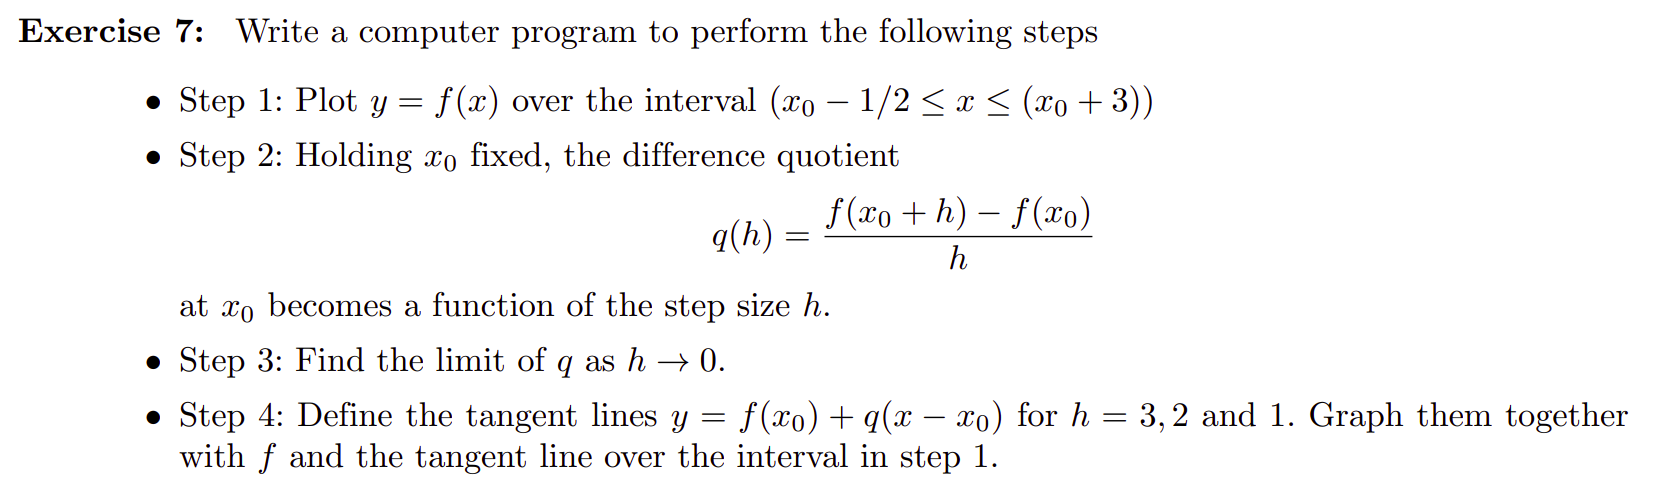

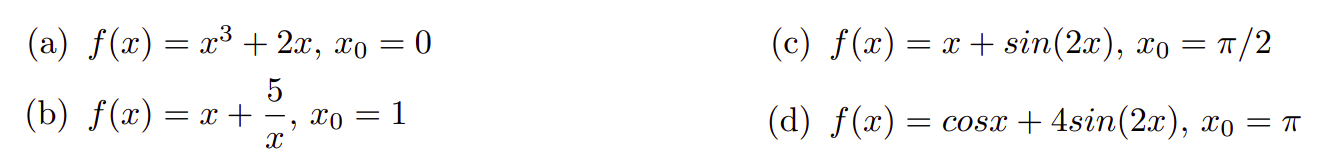

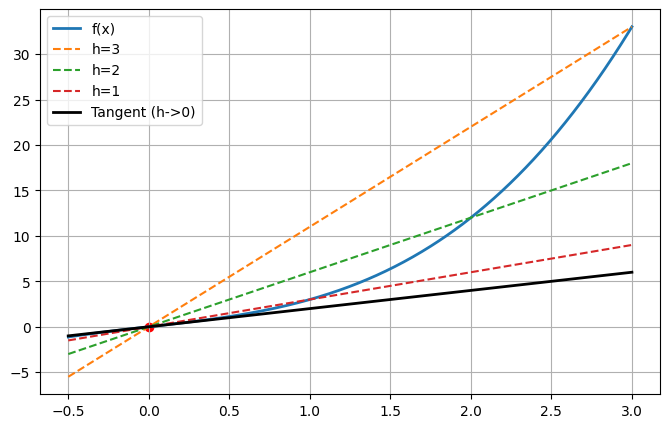

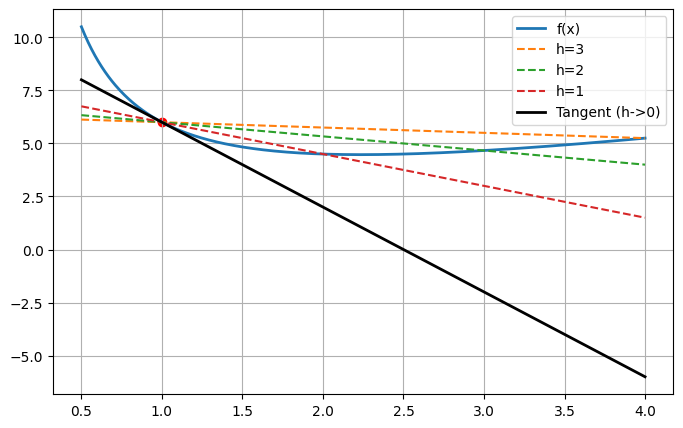

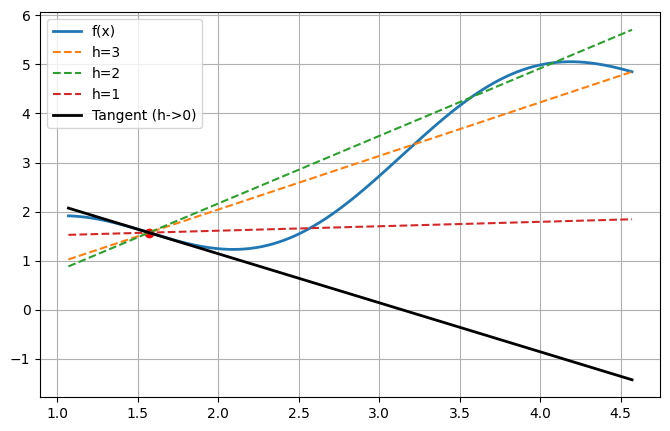

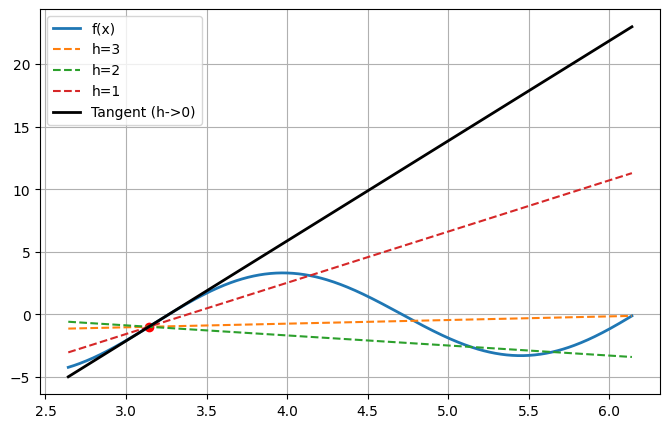

In [2]:
x, h = sp.symbols('x h')

def ex_1(f_expr, x0_val):
    q = (f_expr.subs(x, x0_val + h) - f_expr.subs(x, x0_val)) / h
    limit = sp.limit(q, h, 0)
    
    f_numpy = sp.lambdify(x, f_expr, 'numpy')
    x0_float = float(x0_val.evalf()) if hasattr(x0_val, 'evalf') else float(x0_val)
    
    x_val = np.linspace(x0_float - 0.5, x0_float + 3, 500)
    y_val = f_numpy(x_val)
    
    plt.figure(figsize=(8, 5))
    plt.plot(x_val, y_val, label='f(x)', linewidth=2)
    
    f_x0 = float(f_expr.subs(x, x0_val).evalf())
    
    for h_val in [3, 2, 1]:
        he_so_goc = float(q.subs(h, h_val).evalf())
        y_tan = f_x0 + he_so_goc * (x_val - x0_float)
        plt.plot(x_val, y_tan, '--', label=f'h={h_val}')
        
    m_true = float(limit.evalf())
    y_true_tan = f_x0 + m_true * (x_val - x0_float)
    plt.plot(x_val, y_true_tan, 'k-', linewidth=2, label='Tangent (h->0)')
    
    plt.scatter([x0_float], [f_x0], color='red')
    plt.legend()
    plt.grid(True)
    plt.show()

ex_1(x**3 + 2*x, 0)
ex_1(x + 5/x, 1)
ex_1(x + sp.sin(2*x), sp.pi/2)
ex_1(sp.cos(x) + 4*sp.sin(2*x), sp.pi)

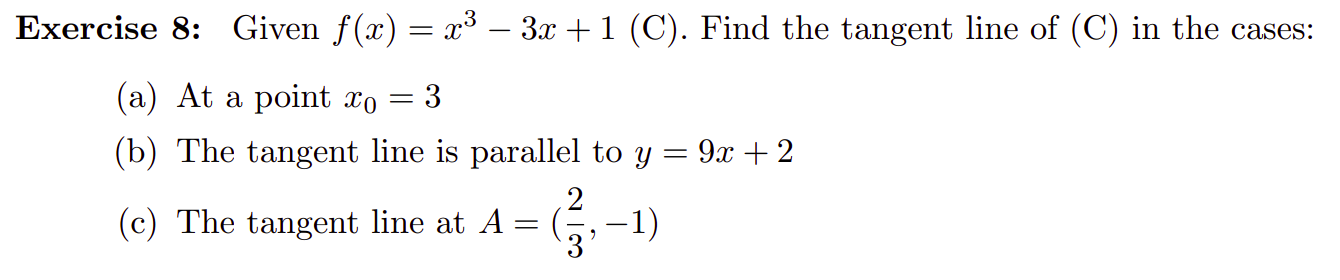

In [3]:
x, a = sp.symbols('x a')
f = x**3 - 3*x + 1
df = sp.diff(f, x)

x0_a = 3
y0_a = f.subs(x, x0_a)
m_a = df.subs(x, x0_a)
tan_a = m_a * (x - x0_a) + y0_a
print(f"(a)\ny = {sp.expand(tan_a)}")

m_b = 9
x0_b_vals = sp.solve(sp.Eq(df, m_b), x)
print("(b)")
for x0_b in x0_b_vals:
    y0_b = f.subs(x, x0_b)
    tan_b = m_b * (x - x0_b) + y0_b
    print(f"y = {sp.expand(tan_b)}")

f_a = a**3 - 3*a + 1
df_a = 3*a**2 - 3
eq_c = sp.Eq(-1, df_a * (sp.Rational(2, 3) - a) + f_a)
a_vals = sp.solve(eq_c, a)
print("(c)")
for a_val in a_vals:
    m_c = df_a.subs(a, a_val)
    y0_c = f_a.subs(a, a_val)
    tan_c = m_c * (x - a_val) + y0_c
    print(f"y = {sp.expand(tan_c)}")

(a)
y = 24*x - 53
(b)
y = 9*x + 17
y = 9*x - 15
(c)
y = 1 - 3*x
y = -1


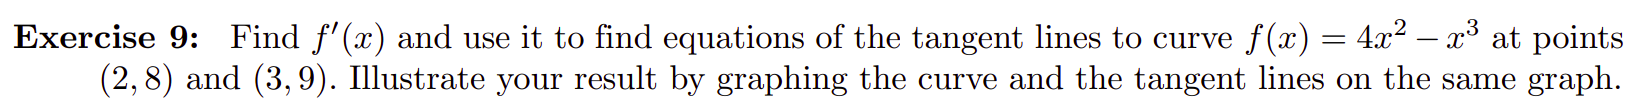

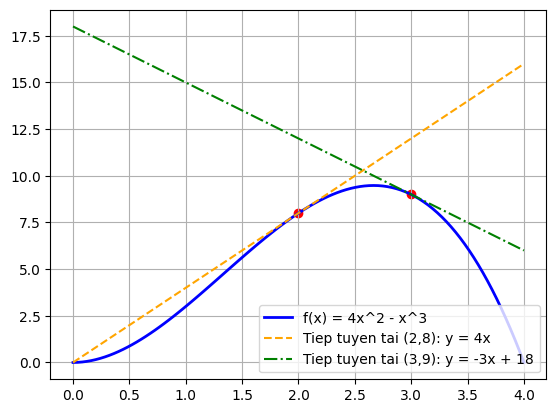

In [4]:
x = np.linspace(0, 4, 100)

plt.plot(x, 4*x**2 - x**3, label='f(x) = 4x^2 - x^3', color='blue', linewidth=2)
plt.plot(x, 4*x, '--', label='Tiep tuyen tai (2,8): y = 4x', color='orange')
plt.plot(x, -3*x + 18, '-.', label='Tiep tuyen tai (3,9): y = -3x + 18', color='green')

plt.scatter([2, 3], [8, 9], color='red')

plt.legend()
plt.grid(True)
plt.show()

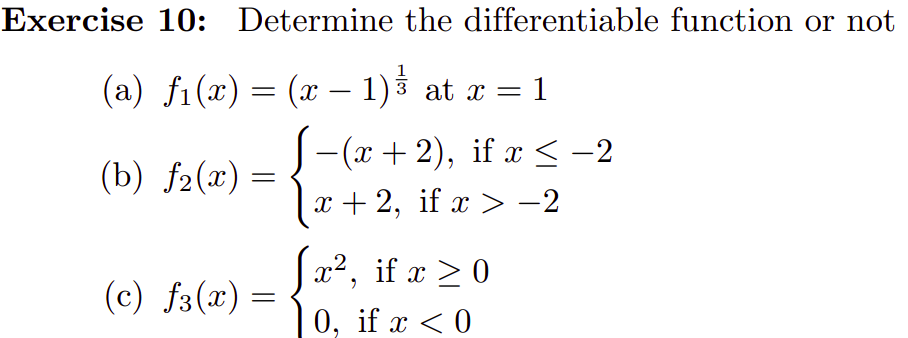

In [5]:


x, h = sp.symbols('x h')

def check_diff(f, x0):
    q = (f.subs(x, x0 + h) - f.subs(x, x0)) / h
    
    L = sp.limit(q, h, 0, dir='-')
    R = sp.limit(q, h, 0, dir='+')
    
    is_diff = (L == R) and not L.has(sp.oo, -sp.oo, sp.zoo)
    
    print(f"Trai = {str(L):>4} | Phai = {str(R):>4}  =>  {'Khả vi' if is_diff else 'Không khả vi'}")

f1 = sp.cbrt(x - 1)
f2 = sp.Piecewise((-(x + 2), x <= -2), (x + 2, x > -2))
f3 = sp.Piecewise((0, x < 0), (x**2, x >= 0))

print("(a) f1 tại x =  1: ", end=""); check_diff(f1, 1)
print("(b) f2 tại x = -2: ", end=""); check_diff(f2, -2)
print("(c) f3 tại x =  0: ", end=""); check_diff(f3, 0)

(a) f1 tại x =  1: Trai = -oo*(-1)**(1/3) | Phai =   oo  =>  Không khả vi
(b) f2 tại x = -2: Trai =   -1 | Phai =   -1  =>  Khả vi
(c) f3 tại x =  0: Trai =    0 | Phai =    0  =>  Khả vi


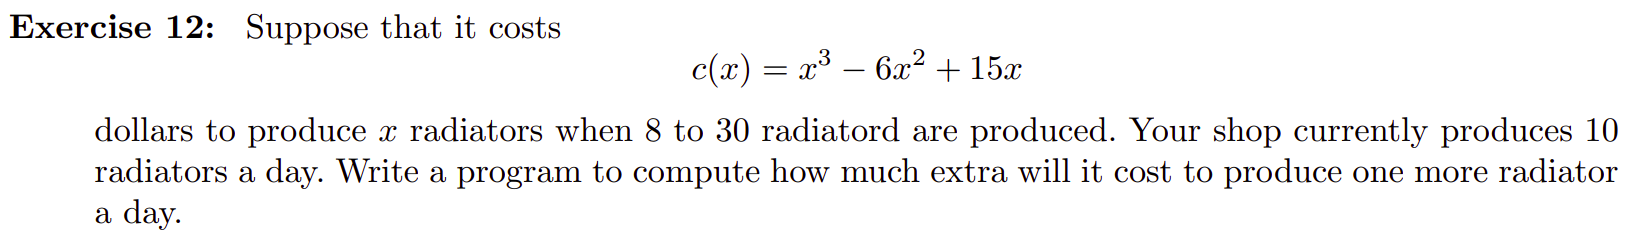

In [6]:
x = sp.symbols('x')
c = x**3 - 6*x**2 + 15*x

dc = sp.diff(c, x)
result = dc.subs(x, 10)

print(result)

195


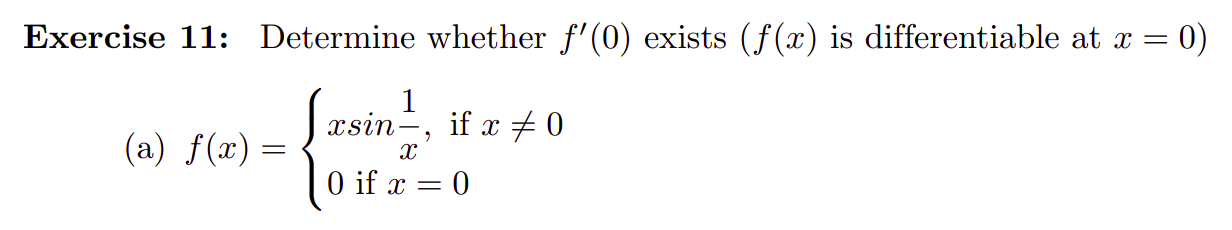

In [7]:

x = sp.symbols('x')

def check_diff_at_zero(f):
    
    q = (f - 0) / (x - 0)
    
    limit_val = sp.limit(q, x, 0)
    
    print(f"Thuong so: {sp.simplify(q)}")
    print(f"Gioi han khi x -> 0: {limit_val}")
    
    if limit_val.is_number:
        print("=> Khả vi \n")
    else:
        print("=> Không khả vi \n")

f_a = x * sp.sin(1/x)
check_diff_at_zero(f_a)

f_b = x**2 * sp.sin(1/x)
check_diff_at_zero(f_b)

Thuong so: sin(1/x)
Gioi han khi x -> 0: AccumBounds(-1, 1)
=> Không khả vi 

Thuong so: x*sin(1/x)
Gioi han khi x -> 0: 0
=> Khả vi 



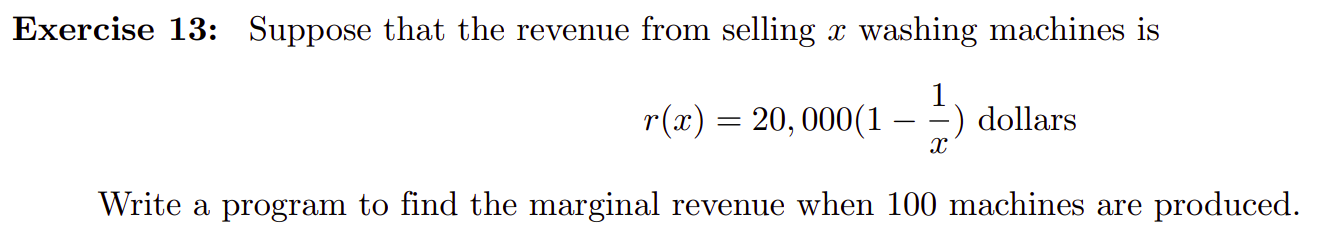

In [8]:
x = sp.symbols('x')
r = 20000 * (1 - 1/x)

dr = sp.diff(r, x)
result = dr.subs(x, 100)

print(result)

2


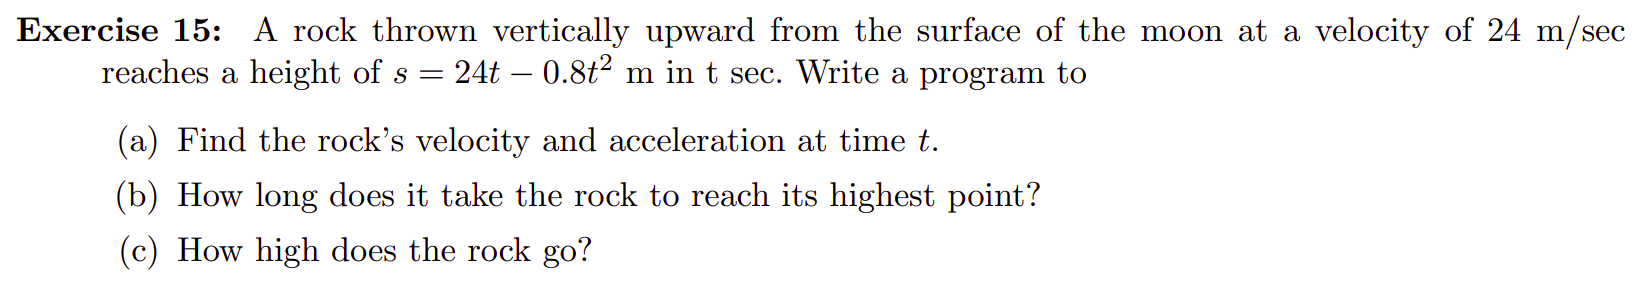

In [9]:

t = sp.symbols('t')
s = 24*t - 0.8*t**2

v = sp.diff(s, t)
a = sp.diff(v, t)
print(f"(a) v(t) = {v}, a(t) = {a}")

t_max = sp.solve(sp.Eq(v, 0), t)[0]
print(f"(b) t = {t_max} sec")

h_max = s.subs(t, t_max)
print(f"(c) Max height = {h_max} m")

(a) v(t) = 24 - 1.6*t, a(t) = -1.60000000000000
(b) t = 15.0000000000000 sec
(c) Max height = 180.000000000000 m
